# ✈️ Operational Bottleneck Identification & Optimization in Airline Industry

## Executive Visual Summary

This notebook presents key insights, visualizations, and findings from the capstone project.

The goal is to provide a quick, visual understanding of:
- Delay patterns
- Airline performance
- Airport congestion
- Optimal flight conditions
- Predictive insights

This serves as a decision-support dashboard for stakeholders.

In [0]:
df = spark.table("tables.default.flights_cleaned")

display(df.limit(5))

YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAYED,DEPARTURE_HOUR,IATA_CODE,AIRLINE_NAME,ROUTE,IS_DELAYED_ARRIVAL,ORIGIN_CONGESTION
2015,1,1,4,DL,2336,N958DN,DEN,ATL,30,24,-6,12,36,173,149,133,1199,449,4,523,453,-30,0,0,null,null,null,null,null,null,null,0,DL,Delta Air Lines Inc.,DEN-ATL,0,912
2015,1,1,4,AA,2392,N3HRAA,DEN,MIA,120,141,21,12,153,227,208,188,1709,701,8,707,709,2,0,0,null,null,null,null,null,null,null,1,AA,American Airlines Inc.,DEN-MIA,1,464
2015,1,1,4,AA,328,N4XKAA,DEN,DFW,530,623,53,32,655,125,138,96,641,931,10,835,941,66,0,0,null,13,0,53,0,0,null,5,AA,American Airlines Inc.,DEN-DFW,1,1960
2015,1,1,4,OO,2599,N435SW,DEN,LAX,545,658,73,11,709,150,133,112,862,801,10,715,811,56,0,0,null,0,0,56,0,0,null,5,OO,Skywest Airlines Inc.,DEN-LAX,1,1960
2015,1,1,4,US,403,N660AW,DEN,PHX,550,550,0,15,605,119,109,91,602,736,3,749,739,-10,0,0,null,null,null,null,null,null,null,5,US,US Airways Inc.,DEN-PHX,0,1960


In [0]:
summary = df.selectExpr(
    "COUNT(*) as total_flights",
    "AVG(CASE WHEN ARRIVAL_DELAY > 0 THEN 1 ELSE 0 END) as delay_rate",
    "AVG(CANCELLED) as cancel_rate",
    "AVG(ARRIVAL_DELAY) as avg_delay"
)

display(summary)

total_flights,delay_rate,cancel_rate,avg_delay
5818795,0.35860001941982833,0.015446497084018254,4.27176537410237


### Overall Performance Insights

This summary provides a high-level overview of flight operations including delay rate, cancellation rate, and average delay duration.

In [0]:
from pyspark.sql import functions as F
airline_perf = df.groupBy("AIRLINE").agg(
    F.count("*").alias("total_flights"),
    F.avg(F.when(F.col("ARRIVAL_DELAY") > 0, 1).otherwise(0)).alias("delay_rate")
)

display(airline_perf.orderBy(F.desc("delay_rate")))

AIRLINE,total_flights,delay_rate
NK,117379,0.4846437608090033
F9,90834,0.4539049254684369
HA,76264,0.3956126088324767
VX,61903,0.3906111173933412
US,198715,0.38389150290617213
B6,267047,0.3819440023666246
OO,588344,0.37805433555878876
WN,1261855,0.3730753533488396
EV,571969,0.3727649575414052
UA,515707,0.3610790623357837


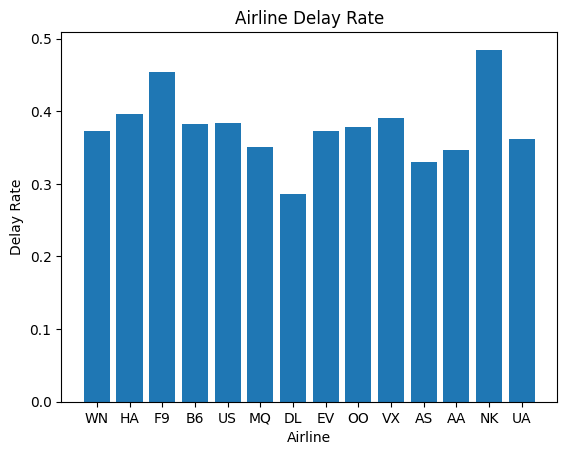

In [0]:
pdf_airline = airline_perf.toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.bar(pdf_airline["AIRLINE"], pdf_airline["delay_rate"])
plt.title("Airline Delay Rate")
plt.xlabel("Airline")
plt.ylabel("Delay Rate")
plt.show()

In [0]:
airport_perf = df.groupBy("ORIGIN_AIRPORT").agg(
    F.count("*").alias("total_flights"),
    F.avg(F.when(F.col("ARRIVAL_DELAY") > 0, 1).otherwise(0)).alias("delay_rate")
).filter("total_flights > 500")

display(airport_perf.orderBy(F.desc("delay_rate")))

ORIGIN_AIRPORT,total_flights,delay_rate
RHI,954,0.48218029350104824
COD,665,0.4706766917293233
OME,663,0.4675716440422323
DLH,1719,0.4525887143688191
OTZ,663,0.4464555052790347
DAL,59699,0.4457696108812543
CIU,613,0.43882544861337686
OAK,42315,0.43502304147465437
CRW,2385,0.4331236897274633
BTR,7164,0.4289503070910106


### Airport Congestion Analysis

High traffic airports show higher delay rates, indicating congestion-driven inefficiencies.

In [0]:
time_analysis = df.groupBy("DEPARTURE_HOUR").agg(
    F.avg(F.when(F.col("ARRIVAL_DELAY") > 0, 1).otherwise(0)).alias("delay_rate")
)

display(time_analysis.orderBy("DEPARTURE_HOUR"))

DEPARTURE_HOUR,delay_rate
0,0.3311511183851609
1,0.3726250484683986
2,0.342998585572843
3,0.30848329048843187
4,0.3465160075329567
5,0.20558111164764786
6,0.24189656104549723
7,0.2733344333456027
8,0.2933764127222429
9,0.3154132267859633


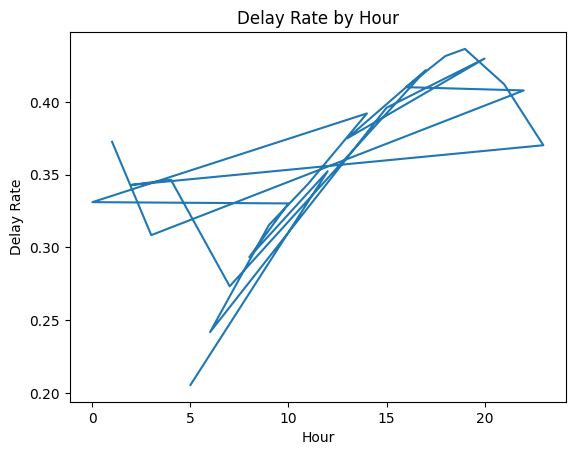

In [0]:
pdf_time = time_analysis.toPandas()

plt.figure()
plt.plot(pdf_time["DEPARTURE_HOUR"], pdf_time["delay_rate"])
plt.title("Delay Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Delay Rate")
plt.show()

In [0]:
route_analysis = df.withColumn(
    "ROUTE",
    F.concat(F.col("ORIGIN_AIRPORT"), F.lit("-"), F.col("DESTINATION_AIRPORT"))
).groupBy("ROUTE").agg(
    F.count("*").alias("total_flights"),
    F.avg(F.when(F.col("ARRIVAL_DELAY") > 0, 1).otherwise(0)).alias("delay_rate")
).filter("total_flights > 300")

display(route_analysis.orderBy(F.desc("delay_rate")).limit(10))

ROUTE,total_flights,delay_rate
DFW-OGG,504,0.6468253968253969
ORD-HNL,334,0.6347305389221557
HOU-JAX,373,0.6246648793565683
ORD-BOI,543,0.6243093922651933
DFW-HNL,695,0.6230215827338129
DEN-HNL,334,0.6137724550898204
IAH-HNL,334,0.6047904191616766
LAS-LBB,334,0.6017964071856288
LAS-FLL,1033,0.5972894482090997
ATL-TTN,325,0.5969230769230769


In [0]:
pdf = df.sample(0.2).toPandas()

best_conditions = (
    pdf.groupby(["DEPARTURE_HOUR"])
    .agg({"IS_DELAYED_ARRIVAL": "mean"})
    .reset_index()
)

best_conditions = best_conditions.sort_values("IS_DELAYED_ARRIVAL")

best_conditions.head(10)

,DEPARTURE_HOUR,IS_DELAYED_ARRIVAL
5,5,0.208993
6,6,0.241934
4,4,0.271186
7,7,0.274834
8,8,0.291768
9,9,0.316158
3,3,0.320442
0,0,0.321697
10,10,0.329181
2,2,0.343173


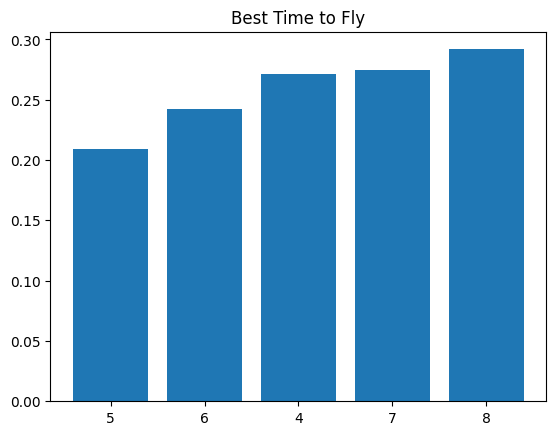

In [0]:
plt.figure()
plt.bar(best_conditions.head(5)["DEPARTURE_HOUR"].astype(str),
        best_conditions.head(5)["IS_DELAYED_ARRIVAL"])
plt.title("Best Time to Fly")
plt.show()

In [0]:
best_conditions.tail(5)

,DEPARTURE_HOUR,IS_DELAYED_ARRIVAL
16,16,0.410872
17,17,0.421826
18,18,0.430637
20,20,0.432232
19,19,0.439525


In [0]:
from sklearn.metrics import accuracy_score
import pandas as pd

results = {
    "Logistic Regression": 0.641384,
    "Decision Tree": 0.640693,
    "Random Forest": 0.641671
}

comparison_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

comparison_df

,Model,Accuracy
0,Logistic Regression,0.641384
1,Decision Tree,0.640693
2,Random Forest,0.641671


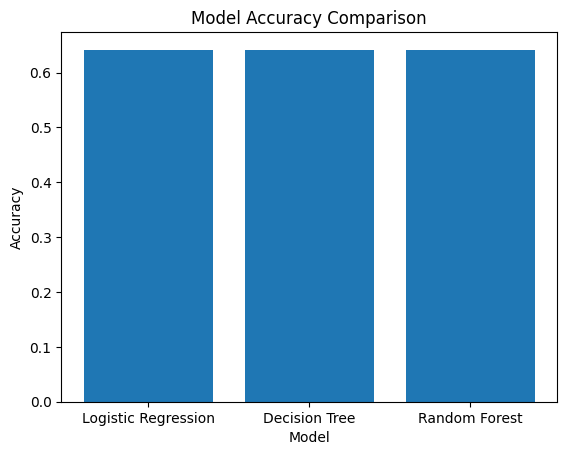

In [0]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(comparison_df["Model"], comparison_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()